# Bayesian Neural Networks for Image Classification
## MTH6161: Neural Networks and Deep Learning — Mini Project

This notebook implements a Bayesian Neural Network (BNN) trained on the
FashionMNIST dataset using Variational Inference. Unlike standard neural
networks which learn point estimates of weights, the BNN maintains a
Gaussian variational posterior over each weight, enabling principled
uncertainty quantification at test time via Monte Carlo sampling.

The notebook is structured as follows:
1. Data loading and preprocessing
2. Model architecture (BayesianLinear layer, BNN, Baseline NN)
3. Training functions
4. Evaluation and results
5. Uncertainty analysis and comparison

In [1]:
# Cell 2 — Imports
import os, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm  # note: tqdm.notebook not tqdm for Colab
import math

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

set_seed(42)
device = get_device()
print(f"Using device: {device}")

Using device: cpu


## 1. Data Loading

We use the FashionMNIST dataset — 70,000 greyscale 28x28 images across
10 clothing categories. The dataset is split into 54,000 training,
6,000 validation, and 10,000 test samples. Both models are trained and
evaluated on identical splits for a fair comparison.

In [2]:
tfm = transforms.Compose([transforms.ToTensor()])

train_full = datasets.FashionMNIST(root="data", train=True,
                                    download=True, transform=tfm)
test_ds = datasets.FashionMNIST(root="data", train=False,
                                 download=True, transform=tfm)

val_frac = 0.1
n_train = int((1-val_frac) * len(train_full))
n_val = len(train_full) - n_train
train_ds, val_ds = random_split(train_full, [n_train, n_val],
                    generator=torch.Generator().manual_seed(42))
#split train with a fixed seed(so that its reproducible)
#validation checks generalisation, this avoids overfitting to train

pin_memory = torch.cuda.is_available()
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True,
                          num_workers=0, pin_memory=pin_memory)
val_loader   = DataLoader(val_ds, batch_size=256, shuffle=False,
                          num_workers=0, pin_memory=pin_memory)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False,
                          num_workers=0, pin_memory=pin_memory)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

100%|██████████| 26.4M/26.4M [00:01<00:00, 21.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 347kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.22MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.1MB/s]


Train: 54000 | Val: 6000 | Test: 10000


## 2. Model Architecture

### BayesianLinear Layer
The core building block of the BNN. Unlike a standard nn.Linear layer
which stores a single weight matrix W, each BayesianLinear layer maintains
two matrices of identical shape:
- **w_mu, b_mu** — means of the weight and bias distributions
- **w_rho, b_rho** — raw scale parameters, from which sigma is computed
  via softplus: sigma = log(1 + exp(rho))

Each forward pass samples weights via the reparameterisation trick
W = mu + sigma * eps, eps ~ N(0,I), computes the linear map, and returns
the KL divergence for that layer alongside the output.

### BNN
Three BayesianLinear layers with ReLU activations and softmax output:

Input (784) → Hidden 1 (200) → Hidden 2 (80) → Output (10)

### Baseline NN  
Standard neural network with identical architecture using fixed point
estimate weights — no distributions, no uncertainty estimates.

In [3]:
#bayesian linear layer, replaces the standard nn.linear
#instead of a single weight matrix W we keep a distribution over weights. For example q(W) = N(mu, sigma^2)
#this means each layer actually has two weight matrices, one matrix for the mu's and one for sigma^2's
#in the forward pass we sample W using the reparameterisation trick so that gradients flow to mu and sigma
#each forward pass also computes kl divergence between q(W,b) and the prior p(w,b)

class BayesianLinear(nn.Module):
    #defining linear layer with uncertainty(each weight and bias has gaussian variational posterior)
    def __init__(self, in_features, out_features, prior_sigma=1.0):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        #variational parameters for weights
        #learning means and raw scales for weights and biases
        self.w_mu = nn.Parameter(torch.zeros(out_features, in_features))
        self.w_rho = nn.Parameter(torch.full((out_features, in_features), -3.0))

        #variational parameters for biases
        self.b_mu = nn.Parameter(torch.zeros(out_features))
        self.b_rho = nn.Parameter(torch.full((out_features,), -3.0))

        #fixing the priors hyperparameters and storing for KL calculation
        self.prior_sigma = torch.tensor(float(prior_sigma))
        self.prior_var = self.prior_sigma**2
        self.log_prior_sigma = torch.log(self.prior_sigma + 1e-8)#using 1e-8 to avoid log(0)

    def _sigma(self, rho):
        #ensuring that sigma is greater than 0 and keeps gradients smooth(rather than using ReLU)
        return torch.log1p(torch.exp(rho))

    def forward(self, x):
        #sample weights and biases through reparameterisation
        w_sigma = self._sigma(self.w_rho)
        b_sigma = self._sigma(self.b_rho)

        eps_w = torch.randn_like(w_sigma)
        eps_b = torch.randn_like(b_sigma)

        W = self.w_mu + w_sigma * eps_w
        b = self.b_mu + b_sigma * eps_b

        #linear map, returns logits for this layer(pre-activation)
        out = x @ W.t() + b

        #closed form kl divergence between two gaussians for each parameter, then sum over all weights/biases
        #this is the regularisation term in the ELBO
        #KL(q||p) for factorised gaussians(summing over all parameters)
        #KL(N(mu, sigma^2) || N(0, prior_sigma^2)) = log(prior_sigma/sigma) + (sigma^2 + mu^2)/(2 prior_sigma^2) - 1/2
        kl_w = (self.log_prior_sigma - torch.log(w_sigma + 1e-8) + (w_sigma ** 2 + self.w_mu ** 2) / (2 * self.prior_var) - 0.5).sum()
        kl_b = (self.log_prior_sigma - torch.log(b_sigma + 1e-8) + (b_sigma**2 + self.b_mu**2) / (2 * self.prior_var) - 0.5).sum()
        kl = kl_w + kl_b

        return out, kl

In [4]:
class BNN(nn.Module):
    def __init__(self, in_dim=28*28, h1=200, h2=80, out_dim=10, prior_sigma=1.0):
        super().__init__()
        #3 bayesian linear layers
        #go from input to h1, then h1 to h2, and then h2 to output
        self.blinear1 = BayesianLinear(in_dim, h1, prior_sigma=prior_sigma)
        self.blinear2 = BayesianLinear(h1, h2, prior_sigma=prior_sigma)
        self.blinear_out = BayesianLinear(h2, out_dim, prior_sigma=prior_sigma)

    def forward(self, x):
        #like the baseline nn x comes in as [batch, 1, 28, 28], we need to flatten to [batch, 784]
        x = x.view(x.size(0), -1)

        #layer1: sample weights, linear map, collect kl1
        #samples weights/biases from the variational posterior
        #computes logits
        #returns the raw pre activation outputs along with the kl divergence term for the layer(regularisation)
        logits1, kl1 = self.blinear1(x)
        h1 = F.relu(logits1)#applying ReLU activation

        #layer 2
        logits2, kl2 = self.blinear2(h1)
        h2 = F.relu(logits2)

        #output layer(logits only, no activation here as these logits will be passed into softmax later when we compute cross entropy)
        logits3, kl3 = self.blinear_out(h2)

        total_kl = kl1 + kl2 + kl3#adding up kl contributions from all layers, to be used later in ELBO
        return logits3, total_kl

In [5]:
class BaselineNN(nn.Module):
    def __init__(self, in_dim=28*28, h1=200, h2=80, out_dim=10):
        super().__init__()
        #identical architecture to BNN but with fixed point estimate weights
        #no distributions, no uncertainty estimates
        self.fc1 = nn.Linear(in_dim, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.fc_out = nn.Linear(h2, out_dim)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc_out(x)

## 3. Training Functions

### BNN Training
At each step we:
1. Sample weights via reparameterisation trick
2. Compute negative ELBO = cross entropy + beta * (KL / N)
3. Backpropagate gradients to mu and sigma
4. Update with Adam optimiser

KL annealing ramps beta from 0 to 1 over the first 5 epochs,
allowing the likelihood term to dominate early training before
the KL regularisation switches on. Without this the KL can
collapse the posterior to the prior before training begins.

### Baseline Training
Standard cross entropy minimisation with Adam — no KL term.

In [6]:
def elbo_loss(logits, targets, kl_sum, batch_size, dataset_size, beta=1.0):
    nll = F.cross_entropy(logits, targets, reduction="mean")#softmax + negative log likelihood all in one go
    #this term corresponds to the expected log likelihood part of the ELBO
    kl_scaled = (kl_sum/dataset_size)*beta
    #kl is the sum of all KL(q(theta) || p(theta)) over all layers for this one weight sample
    #we multiply by beta/N so that when we average over random minibatches, the expected contribution
    #of kl matches the full dataset objective — making the minibatch objective an unbiased estimator of the full ELBO
    #the beta term helps us anneal the kl to stabilise training early on when the likelihood gradients dominate
    loss = nll + kl_scaled
    return loss, nll.detach(), kl_scaled.detach()


def train_epoch_bnn(model, optimiser, loader, device, dataset_size, beta=1.0):
    model.train()
    #putting the model in training mode
    total_loss = total_nll = total_kl = total_correct = total_seen = 0
    #running sums so we can report epoch averages
    for x, y in tqdm(loader, desc="Train", leave=False):
        x, y = x.to(device), y.to(device)
        #iterate over the mini batches(move tensors to cpu/gpu)
        optimiser.zero_grad()
        #clear previous gradient(SGD step starts fresh)
        logits, kl = model(x)
        #forward pass through the BNN
        #kl is the sum of kls from all sampled layers
        loss, nll, kl_s = elbo_loss(logits, y, kl, x.size(0), dataset_size, beta=beta)
        #compute negative ELBO = NLL + scaled KL
        loss.backward()#backpropagation
        optimiser.step()#Adam update

        total_loss += loss.detach().item() * x.size(0)
        total_nll += nll.item() * x.size(0)
        total_kl += kl_s.item() * x.size(0)
        #accumulate sum over examples
        preds = logits.argmax(dim=1)
        total_correct += (preds==y).sum().item()
        total_seen += x.size(0)
        #compute mini_batch accuracy and count examples

    #this loop essentially implements stochastic variational inference
    #per mini batch we estimate negative ELBO and descend its gradient
    return (total_loss/total_seen, total_nll/total_seen,
            total_kl/total_seen, total_correct/total_seen)


@torch.no_grad()
def eval_epoch_bnn(model, loader, device, dataset_size, beta=1.0):
    model.eval()
    total_loss = total_nll = total_kl = total_correct = total_seen = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits, kl = model(x)
        loss, nll, kl_s = elbo_loss(logits, y, kl, x.size(0), dataset_size, beta=beta)
        #same computations as train_epoch_bnn but no backpropagation
        #we still record NLL and KL so we can see the fit vs regularisation at test time

        total_loss += loss.detach().item() * x.size(0)
        total_nll += nll.item() * x.size(0)
        total_kl += kl_s.item() * x.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds==y).sum().item()
        total_seen += x.size(0)

    return (total_loss/total_seen, total_nll/total_seen,
            total_kl/total_seen, total_correct/total_seen)

In [7]:
def train_epoch_baseline(model, optimiser, loader, device):
    model.train()
    total_loss = total_correct = total_seen = 0
    for x, y in tqdm(loader, desc="Train", leave=False):
        x, y = x.to(device), y.to(device)
        optimiser.zero_grad()
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        loss.backward()
        optimiser.step()
        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_seen += x.size(0)
    return total_loss/total_seen, total_correct/total_seen


@torch.no_grad()
def eval_epoch_baseline(model, loader, device):
    model.eval()
    total_loss = total_correct = total_seen = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_seen += x.size(0)
    return total_loss/total_seen, total_correct/total_seen


@torch.no_grad()
def predict_baseline(model, loader, device):
    model.eval()
    all_probs, all_targets = [], []
    for x, y in loader:
        x = x.to(device)
        probs = torch.softmax(model(x), dim=-1)
        all_probs.append(probs.cpu())
        all_targets.append(y)
    probs = torch.cat(all_probs)
    targets = torch.cat(all_targets)
    preds = probs.argmax(dim=1)
    acc = (preds == targets).float().mean().item()
    return {"mean_probs": probs, "preds": preds,
            "targets": targets, "acc": acc}

## 4. Evaluation and Helper Functions

- **mc_predict**: Approximates the posterior predictive distribution via
  50 Monte Carlo weight samples. For each test image draws 50 different
  weight sets from q(theta), runs each forward pass, and returns:
  - Mean predictions (averaged softmax outputs)
  - Predictive entropy (total uncertainty)
  - Expected entropy (aleatoric uncertainty)
  - Mutual information (epistemic uncertainty)

- **expected_calibration_error**: Measures whether confidence scores match
  empirical accuracy across confidence bins. Lower is better, 0 is perfect.

- **plot_reliability**: Plots reliability diagram — a well calibrated model
  follows the diagonal.

In [8]:
# Our Bayesian neural network was trained using VI,
# which gives us an approximate posterior distribution q(W) over the weights.
# However, to make predictions we need the posterior predictive distribution:
# p(y* | x*, D) = ∫ p(y* | x*, W) p(W | D) dW
# This integral is intractable, and VI cannot directly evaluate it.
# Instead, we use Monte Carlo (MC) sampling: draw several samples of W ~ q(W),
# run each through the network, and average the predictions.
# This gives us both predictions and a measure of uncertainty.
@torch.no_grad()
def mc_predict(model, loader, device, n_samples: int = 50):
    #we draw 50 different weight samples per batch and use these to
    #predict the posterior predictive distribution
    model.eval()
    all_mean, all_std = [], []
    all_predH, all_expH = [], []
    all_targets = []
    eps = 1e-12

    for x, y in loader:
        x = x.to(device)

        #fix: sample once into list then stack — avoids double sampling bug
        logits_samples = torch.stack(
            [model(x)[0] for _ in range(n_samples)], dim=0)

        probs_samples = torch.softmax(logits_samples, dim=-1)
        #softmax turns logits into class probabilities for each sample

        mean_probs = probs_samples.mean(dim=0)
        #mean over samples gives the predictive mean
        std_probs = probs_samples.std(dim=0)
        #std over samples captures per class spread across weight samples

        pred_entropy = -(mean_probs *
                        (mean_probs.clamp_min(eps).log())).sum(dim=-1)
        #entropy of the mean distribution = total uncertainty

        per_sample_entropy = -(probs_samples *
                               probs_samples.clamp_min(eps).log()).sum(dim=-1)
        exp_entropy = per_sample_entropy.mean(dim=0)
        #expected entropy = aleatoric uncertainty

        all_mean.append(mean_probs.cpu())
        all_std.append(std_probs.cpu())
        all_predH.append(pred_entropy.cpu())
        all_expH.append(exp_entropy.cpu())
        all_targets.append(y)

    mean_probs = torch.cat(all_mean, dim=0)
    std_probs  = torch.cat(all_std, dim=0)
    predH      = torch.cat(all_predH, dim=0)
    expH       = torch.cat(all_expH, dim=0)
    targets    = torch.cat(all_targets, dim=0)

    #point predictions from the averaged probabilities
    preds = mean_probs.argmax(dim=1)
    acc = (preds==targets).float().mean().item()

    return {
        "mean_probs":  mean_probs,
        "std_probs":   std_probs,
        "pred_entropy": predH,
        "exp_entropy":  expH,
        "mutal_info":   predH - expH,  #epistemic uncertainty
        "preds":        preds,
        "targets":      targets,
        "acc":          acc,
    }


def plot_reliability(probs, targets, n_bins=15, title="Reliability Diagram"):
    conf, pred = probs.max(dim=1)
    correct = (pred == targets).float()
    bins = torch.linspace(0, 1, steps=n_bins+1)
    bin_acc, bin_conf = [], []
    for i in range(n_bins):
        in_bin = (conf > bins[i]) & (conf <= bins[i+1])
        if in_bin.any():
            bin_acc.append(correct[in_bin].mean().item())
            bin_conf.append(conf[in_bin].mean().item())
        else:
            bin_acc.append(np.nan)
            bin_conf.append((bins[i]+bins[i+1])/2)
    bin_acc  = np.array(bin_acc)
    bin_conf = np.array(bin_conf)
    m = ~np.isnan(bin_acc)
    plt.figure(figsize=(4,4))
    plt.plot([0,1],[0,1], 'k--', lw=1)
    plt.bar(bin_conf[m], bin_acc[m]-bin_conf[m],
            width=1/n_bins, bottom=bin_conf[m], alpha=0.6)
    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.tight_layout()


def expected_calibration_error(probs, targets, n_bins=15):
    conf, pred = probs.max(dim=1)
    correct = (pred == targets).float()
    bins = torch.linspace(0, 1, steps=n_bins+1)
    ece = torch.tensor(0.0)
    for i in range(n_bins):
        in_bin = (conf > bins[i]) & (conf <= bins[i+1])
        n = in_bin.sum().item()
        if n > 0:
            acc_bin  = correct[in_bin].mean()
            conf_bin = conf[in_bin].mean()
            ece += (n / len(conf)) * (acc_bin - conf_bin).abs()
    return float(ece)

## 5. Training the Models

We train both models for 10 epochs with identical hyperparameters
(Adam, lr=1e-3, batch size 128) for a fair comparison.

**BNN** additionally uses:
- KL annealing: beta ramps from 0 to 1 over 5 warmup epochs
- KL scaling by N: makes mini-batch loss an unbiased estimator of full ELBO

> **Note on reproducibility:** Due to stochastic weight
> initialisation and the random nature of SGD and Monte Carlo
> sampling, results may vary slightly between runs. A fixed seed
> (`seed=42`) is used where possible to minimise variance, but
> some variation in final accuracy and ECE is expected. The
> figures reported in the accompanying written report reflect
> one representative run.


In [9]:
print("=" * 40)
print("Training Baseline NN")
print("=" * 40)

baseline_model = BaselineNN().to(device)
baseline_opt = torch.optim.Adam(baseline_model.parameters(), lr=1e-3)

for ep in range(1, 11):
    tr_loss, tr_acc = train_epoch_baseline(baseline_model, baseline_opt,
                                           train_loader, device)
    va_loss, va_acc = eval_epoch_baseline(baseline_model, val_loader, device)
    print(f"Epoch {ep:02d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} "
          f"| val loss {va_loss:.4f} acc {va_acc:.4f}")

te_loss, te_acc = eval_epoch_baseline(baseline_model, test_loader, device)
baseline_results = predict_baseline(baseline_model, test_loader, device)
baseline_ece = expected_calibration_error(baseline_results["mean_probs"],
                                          baseline_results["targets"])

print(f"\nTEST | loss {te_loss:.4f} acc {te_acc:.4f}")
print(f"Baseline NN | test acc = {baseline_results['acc']:.4f} "
      f"| ECE = {baseline_ece:.3f}")

Training Baseline NN


Train:   0%|          | 0/422 [00:00<?, ?it/s]

Epoch 01 | train loss 0.6049 acc 0.7928 | val loss 0.4547 acc 0.8395


Train:   0%|          | 0/422 [00:00<?, ?it/s]

Epoch 02 | train loss 0.4085 acc 0.8531 | val loss 0.4009 acc 0.8547


...

Epoch 08 | train loss 0.2729 acc 0.8998 | val loss 0.3279 acc 0.8820


Train:   0%|          | 0/422 [00:00<?, ?it/s]

Epoch 09 | train loss 0.2655 acc 0.9013 | val loss 0.3360 acc 0.8808


Train:   0%|          | 0/422 [00:00<?, ?it/s]

Epoch 10 | train loss 0.2523 acc 0.9063 | val loss 0.3224 acc 0.8863

TEST | loss 0.3378 acc 0.8808
Baseline NN | test acc = 0.8808 | ECE = 0.016


In [10]:
print("=" * 40)
print("Training BNN")
print("=" * 40)

bnn_model = BNN(h1=200, h2=80, prior_sigma=2.0).to(device)
bnn_opt = torch.optim.Adam(bnn_model.parameters(), lr=1e-3)
#instantiate BNN and optimiser — using Adam (adaptive SGD)

epochs = 10
warmup_epochs = 5

for ep in range(1, epochs + 1):
    beta = min(1.0, ep / warmup_epochs)  # ramp up KL weight
    tr_loss, tr_nll, tr_kl, tr_acc = train_epoch_bnn(
        bnn_model, bnn_opt, train_loader, device,
        dataset_size=len(train_ds), beta=beta)
    va_loss, va_nll, va_kl, va_acc = eval_epoch_bnn(
        bnn_model, val_loader, device,
        dataset_size=len(train_ds), beta=beta)
    print(f"Epoch {ep:02d} | train loss {tr_loss:.4f} "
          f"(nll {tr_nll:.4f} + kl {tr_kl:.4f}) acc {tr_acc:.4f} "
          f"| val loss {va_loss:.4f} "
          f"(nll {va_nll:.4f} + kl {va_kl:.4f}) acc {va_acc:.4f}")

#this is our training loop
#we record decomposed loss so we see the ELBO parts
#if nll gets smaller the model fits data better
#change in kl tells us how tightly the posterior stays near the prior

te_loss, te_nll, te_kl, te_acc = eval_epoch_bnn(
    bnn_model, test_loader, device,
    dataset_size=len(train_ds), beta=1.0)
print(f"\nTEST | loss {te_loss:.4f} "
      f"(nll {te_nll:.4f} + kl {te_kl:.4f}) acc {te_acc:.4f}")

#posterior predictive via Monte Carlo
bnn_results = mc_predict(bnn_model, test_loader, device, n_samples=50)
bnn_ece = expected_calibration_error(bnn_results["mean_probs"],
                                     bnn_results["targets"])
print(f"BNN (MC 50 samples) | test acc = {bnn_results['acc']:.4f} "
      f"| ECE = {bnn_ece:.3f}")

Training BNN


Train:   0%|          | 0/422 [00:00<?, ?it/s]

Epoch 01 | train loss 3.4911 (nll 1.4552 + kl 2.0359) acc 0.4016 | val loss 2.8636 (nll 0.8666 + kl 1.9970) acc 0.6568


Train:   0%|          | 0/422 [00:00<?, ?it/s]

Epoch 02 | train loss 4.5186 (nll 0.6559 + kl 3.8626) acc 0.7501 | val loss 4.2821 (nll 0.5400 + kl 3.7421) acc 0.8057


...

Epoch 08 | train loss 6.3197 (nll 0.3816 + kl 5.9381) acc 0.8606 | val loss 6.1673 (nll 0.4157 + kl 5.7516) acc 0.8530


Train:   0%|          | 0/422 [00:00<?, ?it/s]

Epoch 09 | train loss 5.9575 (nll 0.3727 + kl 5.5848) acc 0.8649 | val loss 5.8297 (nll 0.4051 + kl 5.4247) acc 0.8540


Train:   0%|          | 0/422 [00:00<?, ?it/s]

Epoch 10 | train loss 5.6502 (nll 0.3700 + kl 5.2802) acc 0.8635 | val loss 5.5567 (nll 0.4145 + kl 5.1422) acc 0.8537

TEST | loss 5.5781 (nll 0.4359 + kl 5.1422) acc 0.8457
BNN (MC 50 samples) | test acc = 0.8615 | ECE = 0.019


## 6. Results and Analysis

### Comparison Table
We compare the BNN and baseline NN across accuracy and calibration.
A lower ECE indicates better calibration — the model's confidence
scores more closely match its empirical accuracy.

In [11]:
print("=" * 50)
print(f"{'Model':<20} {'Test Acc':>10} {'ECE':>10}")
print("=" * 50)
print(f"{'Baseline NN':<20} "
      f"{baseline_results['acc']:>10.4f} "
      f"{baseline_ece:>10.3f}")
print(f"{'BNN (MC 50)':<20} "
      f"{bnn_results['acc']:>10.4f} "
      f"{bnn_ece:>10.3f}")
print("=" * 50)

Model                  Test Acc        ECE
Baseline NN              0.8808      0.016
BNN (MC 50)              0.8615      0.019


### Reliability Diagrams
A perfectly calibrated model follows the diagonal dashed line.
Bars above the diagonal indicate underconfidence, bars below
indicate overconfidence.

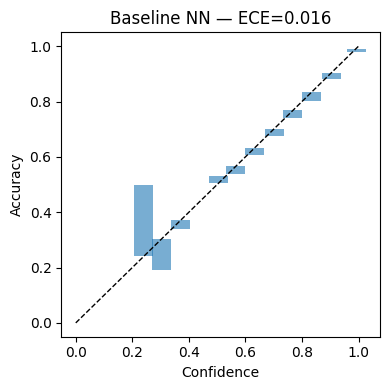

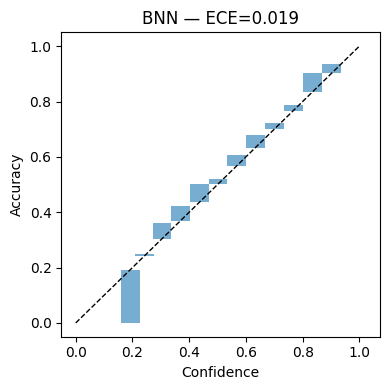

In [12]:
# Reliability diagram - Baseline
plot_reliability(baseline_results["mean_probs"],
                 baseline_results["targets"],
                 title=f"Baseline NN — ECE={baseline_ece:.3f}")
plt.show()

# Reliability diagram - BNN
plot_reliability(bnn_results["mean_probs"],
                 bnn_results["targets"],
                 title=f"BNN — ECE={bnn_ece:.3f}")
plt.show()


### Uncertainty Decomposition (BNN only)

Total predictive uncertainty is decomposed into:
- **Epistemic uncertainty** (mutual information) — from not knowing the
  weights perfectly, reducible with more data
- **Aleatoric uncertainty** (expected entropy) — irreducible noise in
  the data itself

We expect harder classes (e.g. shirt vs pullover) to show higher
epistemic uncertainty.

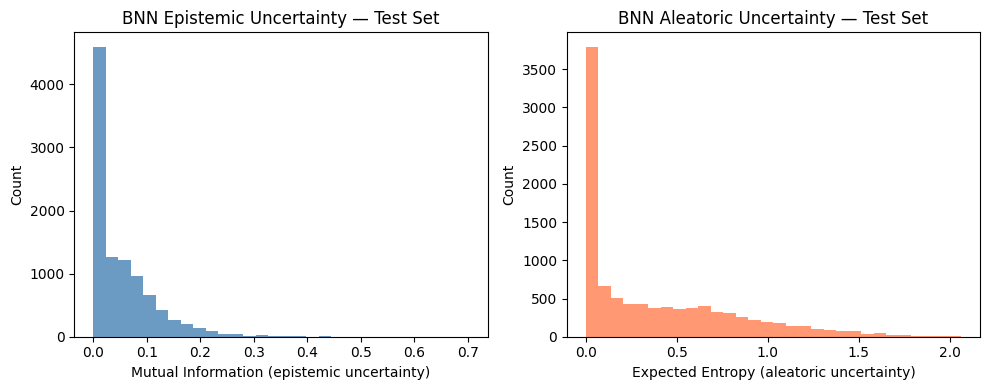

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Mutual information (epistemic uncertainty)
mi = bnn_results["mutal_info"].numpy()
axes[0].hist(mi, bins=30, color="steelblue", alpha=0.8)
axes[0].set_xlabel("Mutual Information (epistemic uncertainty)")
axes[0].set_ylabel("Count")
axes[0].set_title("BNN Epistemic Uncertainty — Test Set")

# Expected entropy (aleatoric uncertainty)
ae = bnn_results["exp_entropy"].numpy()
axes[1].hist(ae, bins=30, color="coral", alpha=0.8)
axes[1].set_xlabel("Expected Entropy (aleatoric uncertainty)")
axes[1].set_ylabel("Count")
axes[1].set_title("BNN Aleatoric Uncertainty — Test Set")

plt.tight_layout()
plt.show()



### Per-Class Analysis

We break down accuracy and epistemic uncertainty by class to identify
where the model struggles and whether uncertainty correlates with difficulty.

FashionMNIST classes:
0: T-shirt, 1: Trouser, 2: Pullover, 3: Dress, 4: Coat,
5: Sandal, 6: Shirt, 7: Sneaker, 8: Bag, 9: Ankle boot

/tmp/ipykernel_6601/609753629.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(class_names, rotation=45, ha="right")
/tmp/ipykernel_6601/609753629.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(class_names, rotation=45, ha="right")


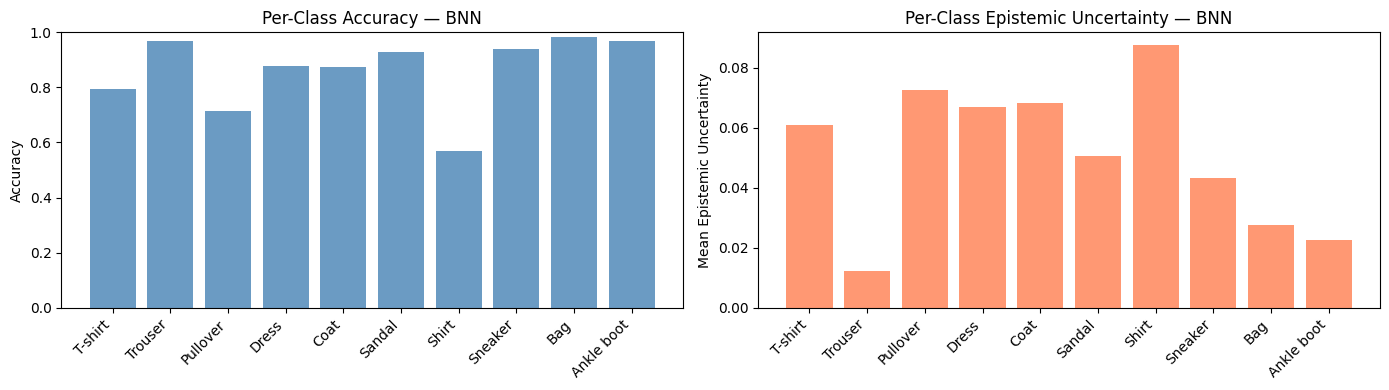


Class          Accuracy   Epistemic Unc
----------------------------------------
T-shirt          0.7950        0.061032
Trouser          0.9690        0.012147
Pullover         0.7130        0.072653
Dress            0.8780        0.066943
Coat             0.8730        0.068177
Sandal           0.9280        0.050621
Shirt            0.5690        0.087440
Sneaker          0.9390        0.043192
Bag              0.9820        0.027612
Ankle boot       0.9690        0.022731


In [14]:
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

targets = bnn_results["targets"]
preds   = bnn_results["preds"]
mi      = bnn_results["mutal_info"]

per_class_acc = []
per_class_mi  = []

for c in range(10):
    mask = (targets == c)
    acc_c = (preds[mask] == targets[mask]).float().mean().item()
    mi_c  = mi[mask].mean().item()
    per_class_acc.append(acc_c)
    per_class_mi.append(mi_c)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(class_names, per_class_acc, color="steelblue", alpha=0.8)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Per-Class Accuracy — BNN")
axes[0].set_xticklabels(class_names, rotation=45, ha="right")
axes[0].set_ylim(0, 1)

axes[1].bar(class_names, per_class_mi, color="coral", alpha=0.8)
axes[1].set_ylabel("Mean Epistemic Uncertainty")
axes[1].set_title("Per-Class Epistemic Uncertainty — BNN")
axes[1].set_xticklabels(class_names, rotation=45, ha="right")

plt.tight_layout()
plt.show()

# Print table
print(f"\n{'Class':<12} {'Accuracy':>10} {'Epistemic Unc':>15}")
print("-" * 40)
for c in range(10):
    print(f"{class_names[c]:<12} {per_class_acc[c]:>10.4f} "
          f"{per_class_mi[c]:>15.6f}")